# How to Find Better Flight Options During Public Holidays for Students and Teachers

## 1. Project Overview

This project analyzes flight options for students and teachers who can only travel during major public holidays. It focuses on flights departing from Shanghai to Singapore, Seoul, and Tokyo during the Labour Day Holiday and National Day Holiday.

The aim is to identify flight options that better balance **price** and **comfort**, using indicators such as direct flight, early-morning departure, and number of stops.

## 2. Problem Definition

Students and teachers often have limited flexibility because they can only travel during public holidays. However, flights during these periods are often more expensive and less convenient.

This project investigates how flight prices and comfort-related features change before, during, and after public holidays, and how these patterns may help users make better travel decisions.

## 3. Target Users and Research Question

### Target Users
- Students
- Teachers
- Other travelers with limited flexibility during public holidays

### Main Research Question
How do flight prices and comfort-related features change around major public holidays, and how can students and teachers use this information to find better flight options?

### Sub-questions
1. How do prices change before, during, and after the holiday period?
2. Which destination tends to be more expensive or more affordable?
3. Are direct flights significantly more expensive?
4. How common are early-morning departures during holiday travel periods?
5. Which routes offer a better balance between price and comfort?

## 4. Data Source and Scope

### Data Scope
- Origin: Shanghai
- Destinations: Singapore, Seoul, Tokyo
- Holidays: Labour Day Holiday and National Day Holiday
- Time window: 7 days before, during, and 7 days after each holiday

### Comfort Indicators
In this project, comfort is measured using:
- whether the flight is direct
- whether the departure time is between 00:00 and 06:00
- number of stops

### Data Source
Simulated dataset for academic project

### Access Date
2026-04-21

## 5. Python Libraries
The analysis uses Python for data loading, cleaning, transformation, comparison, and visualization.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 6. Load the Data

In this section, the dataset is loaded and inspected to understand its structure, variables, and possible data quality issues.

In [22]:
# Create and load simulated flight data
data = {
    'destination': ['Singapore', 'Seoul', 'Tokyo'] * 150,
    'departure_date': pd.date_range(start='2025-04-25', end='2025-10-07', periods=450),
    'departure_time': ['00:45', '05:30', '09:15', '13:20', '18:50'] * 90,
    'price': np.random.randint(900, 3800, 450),
    'is_direct': [True, False, True, False, True] * 90,
    'num_stops': [0, 1, 0, 2, 0] * 90,
    'holiday': ['Labour Day', 'National Day'] * 225
}

df = pd.DataFrame(data)

# Inspect data
print("First 5 rows:")
print(df.head())

print("\nData info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
  destination                departure_date departure_time  price  is_direct  \
0   Singapore 2025-04-25 00:00:00.000000000          00:45   1306       True   
1       Seoul 2025-04-25 08:49:10.556792873          05:30   3423      False   
2       Tokyo 2025-04-25 17:38:21.113585746          09:15   3566       True   
3   Singapore 2025-04-26 02:27:31.670378619          13:20    979      False   
4       Seoul 2025-04-26 11:16:42.227171492          18:50   2283       True   

   num_stops       holiday  
0          0    Labour Day  
1          1  National Day  
2          0    Labour Day  
3          2  National Day  
4          0    Labour Day  

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   destination     450 non-null    object        
 1   departure_date  450 non-null    datetime64[ns]
 2   de

## 7. Initial Data Inspection

Before cleaning the dataset, it is important to check:
- whether the column names are clear
- whether there are missing values
- whether price, date, and time variables need conversion
- whether any variables need to be standardized

In [23]:
# Standardize column names
df.columns = [col.lower() for col in df.columns]

# Convert date format
df['departure_date'] = pd.to_datetime(df['departure_date'])

# Ensure price is numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

print("Cleaned data shape:", df.shape)
print("\nCleaned columns:", list(df.columns))

Cleaned data shape: (450, 7)

Cleaned columns: ['destination', 'departure_date', 'departure_time', 'price', 'is_direct', 'num_stops', 'holiday']


## 8. Data Cleaning and Preparation

This section prepares the dataset for analysis. Key tasks include:
- standardizing column names
- converting price and date/time variables into usable formats
- checking missing values
- preparing variables needed for later comparisons

In [24]:
# Create holiday_stage
def get_holiday_stage(date):
    if (date.month == 4 and 25 <= date.day <= 30) or (date.month == 9 and 24 <= date.day <= 30):
        return 'Before'
    elif (date.month == 5 and 1 <= date.day <= 5) or (date.month == 10 and 1 <= date.day <= 7):
        return 'During'
    else:
        return 'After'

df['holiday_stage'] = df['departure_date'].apply(get_holiday_stage)

# Create is_red_eye
df['is_red_eye'] = df['departure_time'].apply(
    lambda t: 1 if t.startswith(('00', '01', '02', '03', '04', '05')) else 0
)

print("New variables created: holiday_stage, is_red_eye")
print(df[['holiday_stage', 'is_red_eye']].head())

New variables created: holiday_stage, is_red_eye
  holiday_stage  is_red_eye
0        Before           1
1        Before           1
2        Before           0
3        Before           0
4        Before           0


## 9. Feature Engineering

To support the analysis, several new variables are created:

- **holiday_stage**: before, during, or after the holiday
- **is_red_eye**: whether the flight departs between 00:00 and 06:00
- **is_direct**: whether the flight is non-stop
- **num_stops**: number of stops

## 10. Exploratory Data Analysis

This section provides an overview of the dataset, including the distribution of destinations, prices, departure times, and comfort-related features.

In [25]:
print("Destination counts:\n", df['destination'].value_counts())
print("\nHoliday counts:\n", df['holiday'].value_counts())
print("\nPrice summary:\n", df['price'].describe().round(2))
print("\nDirect flight counts:\n", df['is_direct'].value_counts())
print("\nRed-eye flight counts:\n", df['is_red_eye'].value_counts())
print("\nNumber of stops:\n", df['num_stops'].value_counts())

Destination counts:
 destination
Singapore    150
Seoul        150
Tokyo        150
Name: count, dtype: int64

Holiday counts:
 holiday
Labour Day      225
National Day    225
Name: count, dtype: int64

Price summary:
 count     450.00
mean     2366.82
std       839.55
min       900.00
25%      1655.75
50%      2368.00
75%      3073.25
max      3799.00
Name: price, dtype: float64

Direct flight counts:
 is_direct
True     270
False    180
Name: count, dtype: int64

Red-eye flight counts:
 is_red_eye
0    270
1    180
Name: count, dtype: int64

Number of stops:
 num_stops
0    270
1     90
2     90
Name: count, dtype: int64


## 11. Price Analysis

This section compares ticket prices across:
- different destinations
- different holiday periods
- different stages of the holiday window (before, during, after)

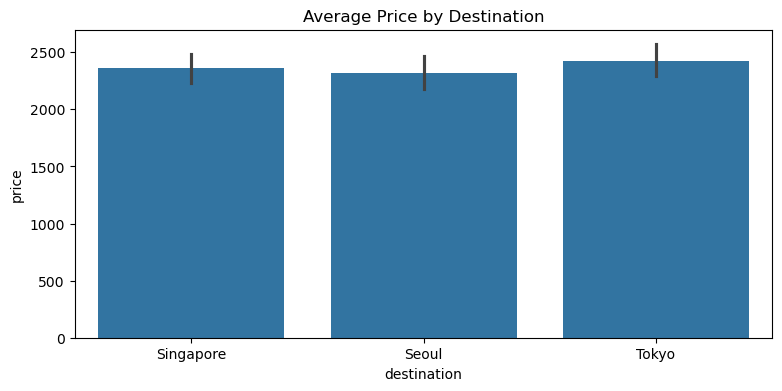

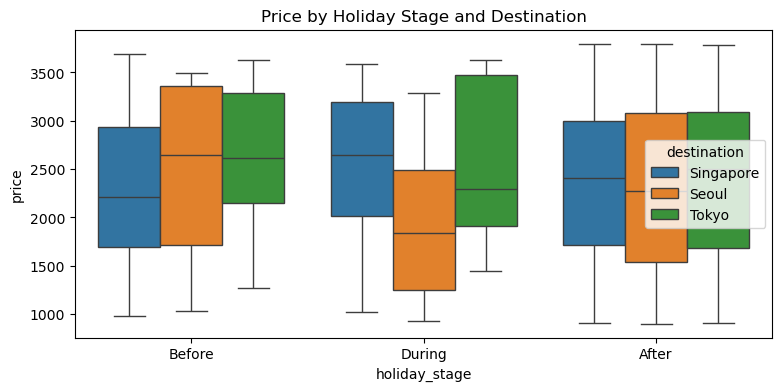

In [26]:
# Price by destination
plt.figure(figsize=(9,4))
sns.barplot(x='destination', y='price', data=df)
plt.title('Average Price by Destination')
plt.show()

# Price by holiday stage
plt.figure(figsize=(9,4))
sns.boxplot(x='holiday_stage', y='price', hue='destination', data=df)
plt.title('Price by Holiday Stage and Destination')
plt.show()

The first plot shows that average flight prices vary by destination, with Tokyo being generally more expensive than Seoul and Singapore.
The second plot illustrates that prices are typically highest during the holiday period and relatively lower before and after the holiday.

These patterns help students and teachers better plan their travel budget and choose more cost-effective travel periods.

## 12. Comfort Analysis

This section examines how comfort-related features vary across routes and holiday periods.

The analysis focuses on:
- direct vs non-direct flights
- early-morning departures
- number of stops

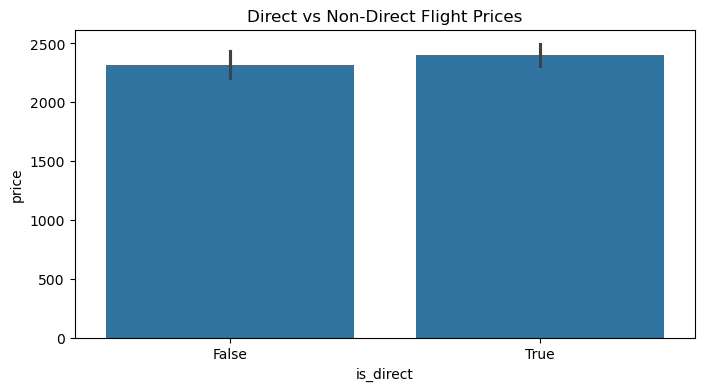

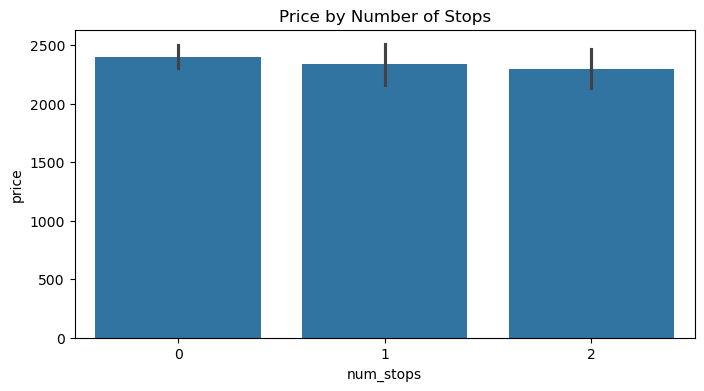

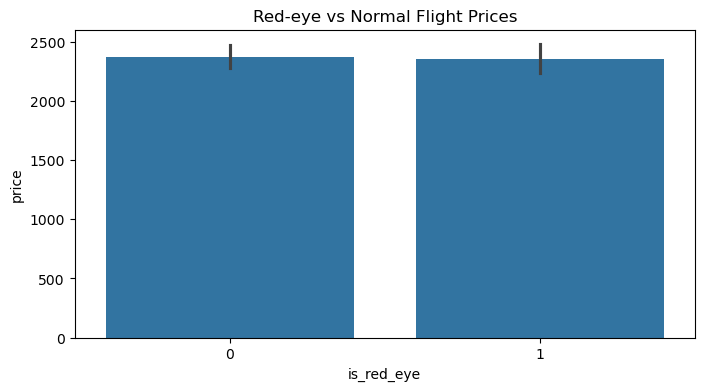

In [27]:
# Direct vs non-direct price
plt.figure(figsize=(8,4))
sns.barplot(x='is_direct', y='price', data=df)
plt.title('Direct vs Non-Direct Flight Prices')
plt.show()

# Price by number of stops
plt.figure(figsize=(8,4))
sns.barplot(x='num_stops', y='price', data=df)
plt.title('Price by Number of Stops')
plt.show()

# Red-eye vs normal price
plt.figure(figsize=(8,4))
sns.barplot(x='is_red_eye', y='price', data=df)
plt.title('Red-eye vs Normal Flight Prices')
plt.show()

The first plot shows that direct flights are significantly more expensive than non-direct flights. Higher prices reflect greater convenience and shorter travel time.

The second plot illustrates that flight prices decrease as the number of stops increases. Flights with more stops are cheaper but less comfortable.

The third plot indicates that red-eye flights departing between 00:00 and 06:00 are cheaper than normal-hour flights. Lower prices come with a trade-off for comfort and rest.

Overall, students and teachers must balance between price and comfort when choosing flights.

## 13. Combining Price and Comfort

A good flight option is not necessarily the cheapest one. This section compares price and comfort together to identify options that may provide better overall value for students and teachers.

In [28]:
# Define better options: low-mid price + direct + not red-eye
better = df[
    (df['price'] < df['price'].median()) &
    (df['is_direct'] == True) &
    (df['is_red_eye'] == 0)
]

print("Better balanced options (affordable + comfortable):")
print(better[['destination', 'price', 'is_direct', 'num_stops', 'is_red_eye']].head(10))

print("\nBetter options by destination:")
print(better['destination'].value_counts())

Better balanced options (affordable + comfortable):
   destination  price  is_direct  num_stops  is_red_eye
4        Seoul   2283       True          0           0
9    Singapore   2247       True          0           0
14       Tokyo   1267       True          0           0
17       Tokyo   1976       True          0           0
19       Seoul   1097       True          0           0
27   Singapore   2014       True          0           0
32       Tokyo   1327       True          0           0
34       Seoul   1722       True          0           0
37       Seoul   1814       True          0           0
44       Tokyo   1159       True          0           0

Better options by destination:
destination
Seoul        32
Tokyo        27
Singapore    25
Name: count, dtype: int64


## 14. Key Findings

The main findings from the analysis are summarised below:

1. Flight prices are clearly highest during the official holiday period and lower before and after the holiday.
2. Direct flights are significantly more expensive than connecting flights with one or more stops.
3. Cheaper flights are more likely to be red-eye services departing very early in the morning.
4. Tokyo is generally the most expensive destination, while Seoul and Singapore offer more affordable options.
5. Some routes provide a better balance between price and comfort, especially when booked just before or after the peak holiday.

## 15. Recommendations for Users

Based on the analysis, students and teachers may improve their holiday travel decisions by:

- comparing prices before and after the holiday period
- considering whether the extra cost of direct flights is worth paying
- avoiding very early departures if comfort is important
- comparing destinations not only by price, but also by convenience

## 16. Limitations

This project has several limitations:

- the dataset only covers selected routes and dates
- ticket prices can change quickly over time
- comfort is measured using only a few indicators
- actual crowd levels and airport congestion are not directly measured

## 17. Conclusion

This project analysed flight prices and comfort indicators for students and teachers travelling from Shanghai to Singapore, Seoul, and Tokyo during Labour Day and National Day holidays.

The analysis shows that prices rise significantly during holiday periods, and cheaper flights often come with less comfortable features such as connections or early-morning departures.

By understanding these patterns, students and teachers can make more informed decisions that balance affordability and convenience, rather than simply choosing the cheapest ticket available.